Conjunto de datos WINE.
URL: https://archive.ics.uci.edu/dataset/186/wine+quality

Librerias para el codigo

In [3]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings("ignore")

Descarga del Dataset Wine

In [5]:
# =========================================================
# 1. DESCARGAR DATASET
# =========================================================
wine_quality = fetch_ucirepo(id=186)

X = wine_quality.data.features.copy()
y = wine_quality.data.targets.copy()

print("=== METADATA ===")
print(wine_quality.metadata)

print("\n=== VARIABLE INFORMATION ===")
print(wine_quality.variables)

=== METADATA ===
{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling

PREPROCESAMIENTO Y VISUALIZACION DEL DATASET


=== INFORMACIÓN DEL DATASET ===
Dimensiones de X: (6497, 11)
Distribución de clases:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Número de clases: 7
Clases detectadas: [3 4 5 6 7 8 9]


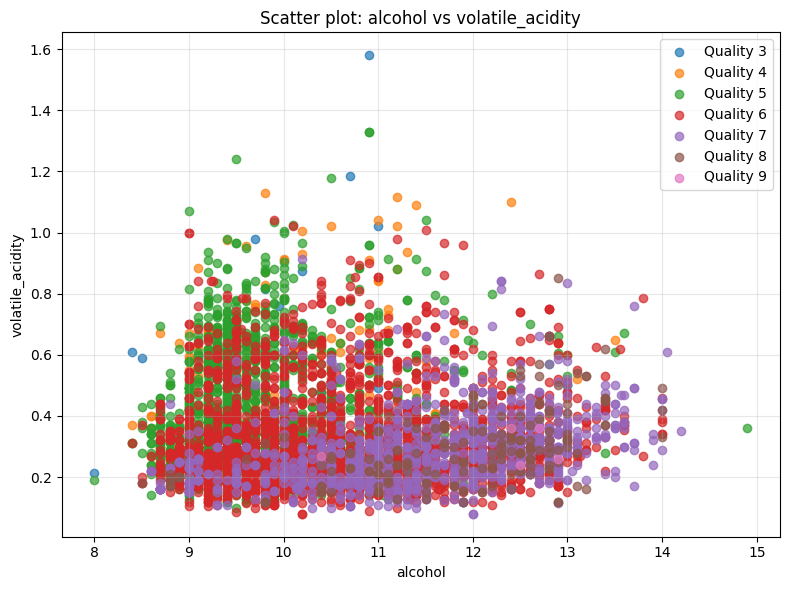

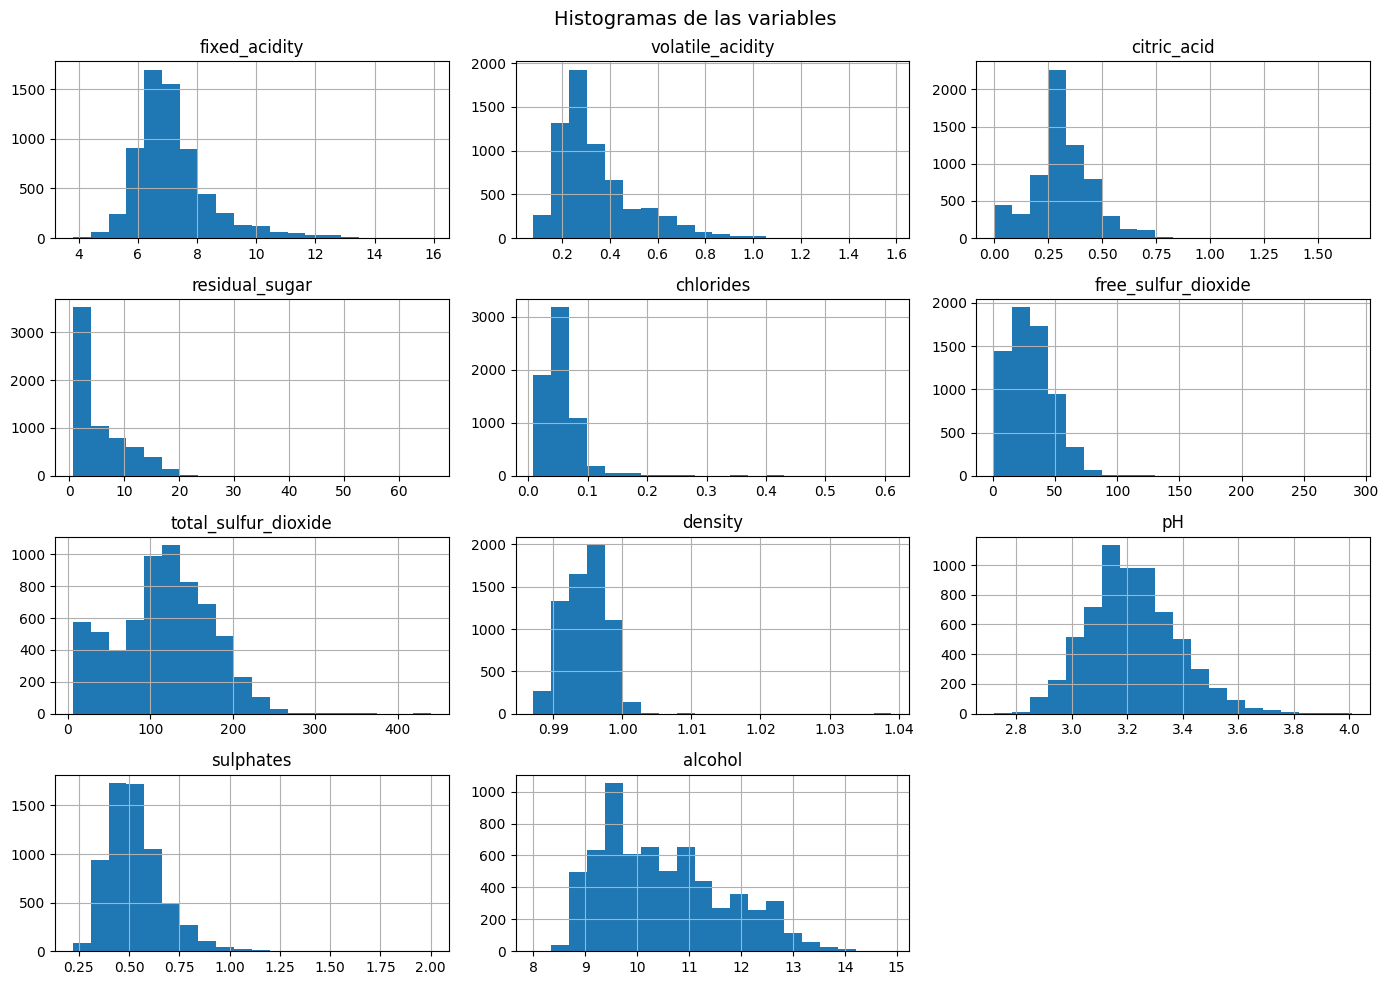

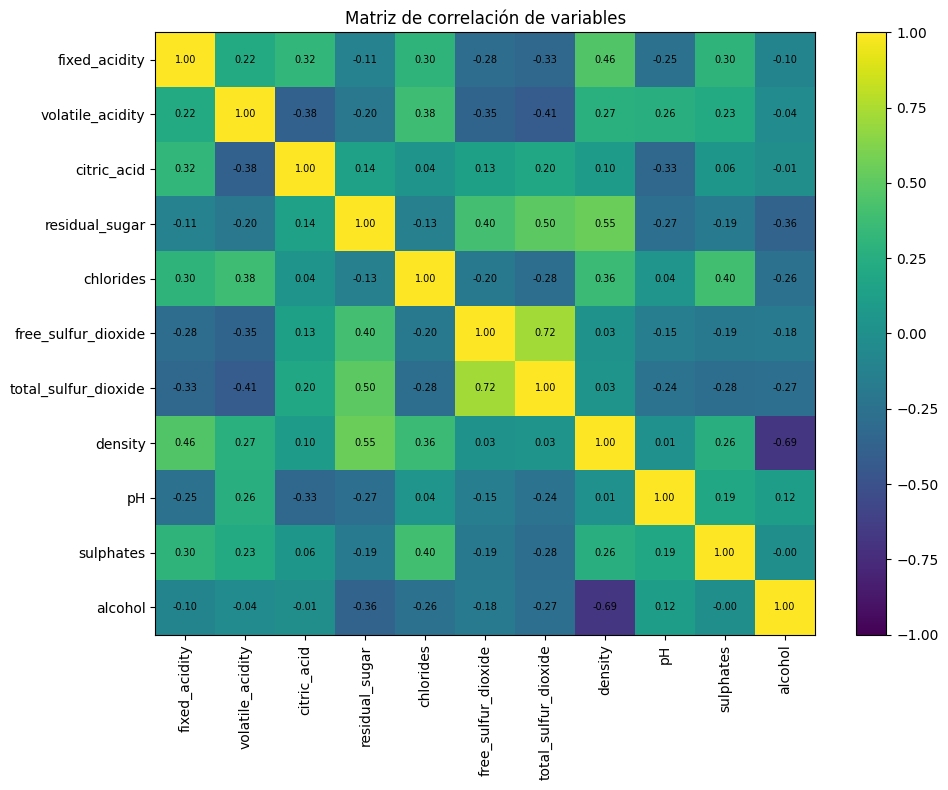

In [7]:
# =========================================================
# 2. PREPROCESADO + VISUALIZACIÓN
# =========================================================
# y puede venir como DataFrame de una columna
if isinstance(y, pd.DataFrame):
    y = y.squeeze()

# Reemplazar '?' por NaN si existiera
X = X.replace("?", np.nan)
y = y.replace("?", np.nan)

# Convertir a numérico
X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y, errors="coerce")

# Eliminar filas sin target
mask = y.notna()
X = X.loc[mask].reset_index(drop=True)
y = y.loc[mask].reset_index(drop=True)

# Si el target es entero, convertirlo a int para verlo mejor
if np.all(np.isclose(y.astype(float), np.round(y.astype(float)))):
    y = y.round().astype(int)

print("\n=== INFORMACIÓN DEL DATASET ===")
print(f"Dimensiones de X: {X.shape}")
print("Distribución de clases:")
print(y.value_counts().sort_index())

classes = np.sort(y.unique())
n_classes = len(classes)

print(f"\nNúmero de clases: {n_classes}")
print(f"Clases detectadas: {classes}")


# =========================================================
# 2.1 VISUALIZACIÓN DE LOS DATOS
# =========================================================
df_viz = X.copy()
df_viz["quality"] = y

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

# ---------------------------------------------------------
# A) SCATTER PLOT
# ---------------------------------------------------------
preferred_pairs = [
    ("alcohol", "volatile_acidity"),
    ("alcohol", "density"),
    ("fixed_acidity", "citric_acid"),
    ("residual_sugar", "density")
]

x_col, y_col = None, None
for c1, c2 in preferred_pairs:
    if c1 in numeric_cols and c2 in numeric_cols:
        x_col, y_col = c1, c2
        break

# Si no existen esas variables, usar las dos primeras numéricas
if (x_col is None or y_col is None) and len(numeric_cols) >= 2:
    x_col, y_col = numeric_cols[0], numeric_cols[1]

if x_col is not None and y_col is not None:
    plt.figure(figsize=(8, 6))
    scatter_mask = df_viz[x_col].notna() & df_viz[y_col].notna()

    for cls in classes:
        subset = df_viz.loc[scatter_mask & (df_viz["quality"] == cls)]
        plt.scatter(
            subset[x_col],
            subset[y_col],
            alpha=0.7,
            label=f"Quality {cls}"
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"Scatter plot: {x_col} vs {y_col}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# B) HISTOGRAMAS
# ---------------------------------------------------------
X.hist(figsize=(14, 10), bins=20)
plt.suptitle("Histogramas de las variables", fontsize=14)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# C) MATRIZ DE CORRELACIÓN
# ---------------------------------------------------------
corr_matrix = X.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, interpolation="nearest", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im)

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Matriz de correlación de variables")

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()
plt.show()

MODELO DE LA RED NEURONAL

In [9]:
# =========================================================
# 3. MODELO MLP
# =========================================================
modelo = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 32),   # dos capas ocultas
        activation="relu",             # función de activación ReLU
        solver="adam",
        alpha=1e-4,
        batch_size=32,
        learning_rate_init=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=20,
        random_state=42
    ))
])

print("\n=== ARQUITECTURA DE LA RED ===")
print("Capas ocultas:", modelo.named_steps["mlp"].hidden_layer_sizes)
print("Función de activación:", modelo.named_steps["mlp"].activation)


=== ARQUITECTURA DE LA RED ===
Capas ocultas: (64, 32)
Función de activación: relu


VALIDACIÓN CRUZADA K-FOLD

In [11]:
# =========================================================
# 4. VALIDACIÓN CRUZADA K-FOLD
# =========================================================
requested_folds = 10
min_class_count = int(y.value_counts().min())

if min_class_count < requested_folds:
    print("\n[AVISO]")
    print(
        f"La clase minoritaria tiene solo {min_class_count} muestras. "
        f"No es posible usar StratifiedKFold con k={requested_folds}. "
        f"Se ajustará automáticamente a k={min_class_count}."
    )

n_splits = min(requested_folds, min_class_count)

cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Métricas adaptadas a multiclase
if n_classes == 2:
    scoring = {
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc"
    }
else:
    scoring = {
        "accuracy": "accuracy",
        "precision_macro": "precision_macro",
        "recall_macro": "recall_macro",
        "f1_macro": "f1_macro",
        "roc_auc_ovr_weighted": "roc_auc_ovr_weighted"
    }

cv_results = cross_validate(
    modelo,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print(f"\n=== RESULTADOS VALIDACIÓN CRUZADA ({n_splits}-FOLD) ===")
for metric in scoring.keys():
    scores = cv_results[f"test_{metric}"]
    print(f"{metric.upper():20s}: {scores.mean():.4f} ± {scores.std():.4f}")

# Predicciones globales usando CV
y_pred = cross_val_predict(modelo, X, y, cv=cv, method="predict", n_jobs=-1)
y_prob = cross_val_predict(modelo, X, y, cv=cv, method="predict_proba", n_jobs=-1)




[AVISO]
La clase minoritaria tiene solo 5 muestras. No es posible usar StratifiedKFold con k=10. Se ajustará automáticamente a k=5.

=== RESULTADOS VALIDACIÓN CRUZADA (5-FOLD) ===
ACCURACY            : 0.5656 ± 0.0179
PRECISION_MACRO     : 0.3020 ± 0.0615
RECALL_MACRO        : 0.2453 ± 0.0191
F1_MACRO            : 0.2485 ± 0.0232
ROC_AUC_OVR_WEIGHTED: 0.7487 ± 0.0170


EVALUACION DEL MLP


=== EVALUACIÓN GLOBAL ===
Accuracy: 0.5656

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00        30
           4       0.42      0.05      0.09       216
           5       0.62      0.62      0.62      2138
           6       0.55      0.69      0.61      2836
           7       0.51      0.34      0.41      1079
           8       0.25      0.01      0.02       193
           9       0.00      0.00      0.00         5

    accuracy                           0.57      6497
   macro avg       0.34      0.25      0.25      6497
weighted avg       0.55      0.57      0.54      6497

ROC AUC OVR Weighted: 0.7484


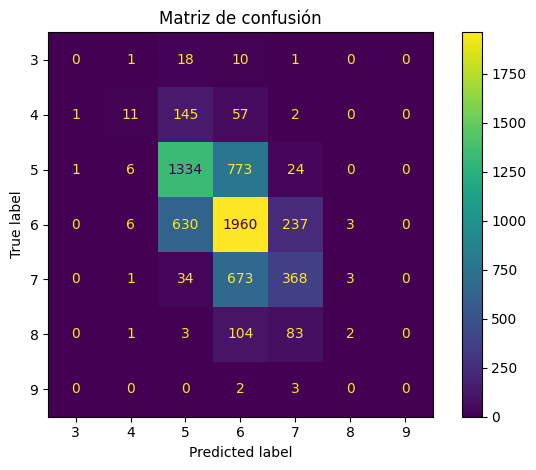

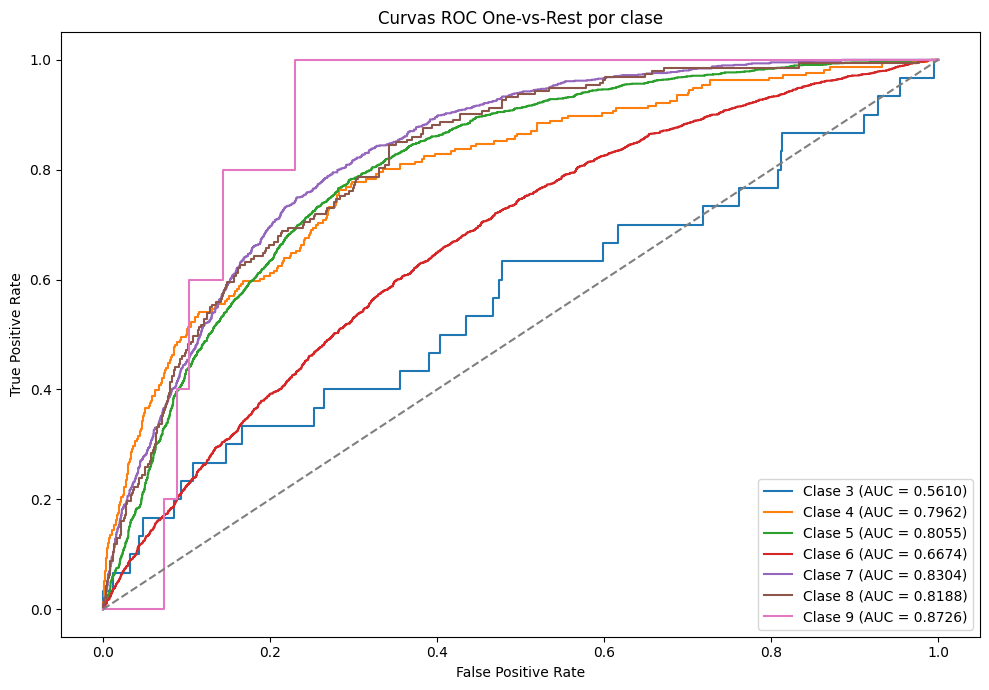


=== RED ENTRENADA FINAL ===
Capas ocultas: (64, 32)
Activación: relu
Número total de capas: 4
Tamaño de la capa de salida: 7
Clases de salida: [3 4 5 6 7 8 9]


In [13]:
# =========================================================
# 5. EVALUACIÓN
# =========================================================
acc = accuracy_score(y, y_pred)

print("\n=== EVALUACIÓN GLOBAL ===")
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y, y_pred))

if n_classes == 2:
    auc = roc_auc_score(y, y_prob[:, 1])
    print(f"ROC AUC:  {auc:.4f}")
else:
    auc = roc_auc_score(y, y_prob, multi_class="ovr", average="weighted")
    print(f"ROC AUC OVR Weighted: {auc:.4f}")

# Matriz de confusión
cm = confusion_matrix(y, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot()
plt.title("Matriz de confusión")
plt.tight_layout()
plt.show()


# =========================================================
# 6. CURVAS ROC
# =========================================================
if n_classes == 2:
    fpr, tpr, _ = roc_curve(y, y_prob[:, 1])
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curva ROC")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    y_bin = label_binarize(y, classes=classes)

    plt.figure(figsize=(10, 7))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        auc_cls = roc_auc_score(y_bin[:, i], y_prob[:, i])
        plt.plot(fpr, tpr, label=f"Clase {cls} (AUC = {auc_cls:.4f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Curvas ROC One-vs-Rest por clase")
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 7. ENTRENAR MODELO FINAL SOBRE TODO EL CONJUNTO
# =========================================================
modelo.fit(X, y)

mlp_final = modelo.named_steps["mlp"]
print("\n=== RED ENTRENADA FINAL ===")
print("Capas ocultas:", mlp_final.hidden_layer_sizes)
print("Activación:", mlp_final.activation)
print("Número total de capas:", mlp_final.n_layers_)
print("Tamaño de la capa de salida:", mlp_final.n_outputs_)
print("Clases de salida:", mlp_final.classes_)